In [1]:
pip install opencv-python numpy matplotlib rasterio scikit-image

In [2]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the path to your SIH folder
# Update this path if 'sih_chandrayaan2' is inside a subfolder (e.g., 'My Drive/SIH/sih_chandrayaan2')
DRIVE_FOLDER_PATH = '/content/drive/My Drive/sih_chandrayaan2'

# 3. Verify and list files in your folder
if os.path.exists(DRIVE_FOLDER_PATH):
    print("Folder found! Here are your files:\n")
    files = os.listdir(DRIVE_FOLDER_PATH)
    for f in sorted(files):
        print(f" - {f}")
else:
    print(f"Directory not found at: {DRIVE_FOLDER_PATH}")
    print("Please check the exact path in your Google Drive.")

Mounted at /content/drive
Folder found! Here are your files:

 - ch2_iir_nci_20201230T1639134520_d_img_d32.qub
 - ch2_iir_nci_20201230T1639134520_d_img_d32.xml
 - ch2_iir_nci_20201231T1417233990_d_img_d32.qub
 - ch2_iir_nci_20201231T1417233990_d_img_d32.xml
 - ch2_ohr_ncp_20211228T2209123959_d_img_d18 (1).img
 - ch2_ohr_ncp_20211228T2209123959_d_img_d18 (1).xml
 - ch2_ohr_ncp_20211228T2209123959_d_img_d18.img
 - ch2_ohr_ncp_20211228T2209123959_d_img_d18.xml
 - ch2_ohr_ncp_20220321T0326368312_d_img_hw1.img
 - ch2_ohr_ncp_20220321T0326368312_d_img_hw1.xml
 - ch2_ohr_ncp_20220321T0326369085_d_img_d18.img
 - ch2_ohr_ncp_20220321T0326369085_d_img_d18.xml
 - ch2_ohr_ncp_20220321T0326369860_d_img_d18.img
 - ch2_ohr_ncp_20220321T0326369860_d_img_d18.xml
 - ch2_ohr_ncp_20220321T0525225877_d_img_hw1.img
 - ch2_ohr_ncp_20220321T0525225877_d_img_hw1.xml
 - ch2_ohr_ncp_20220321T0525226030_d_img_d18.img
 - ch2_ohr_ncp_20220321T0525226030_d_img_d18.xml
 - ch2_ohr_ncp_20241115T1326321339_d_img_d18 (1)

--- Running Step 1 (XML-Guided Ingestion & Preprocessing) ---
[ch2_ohr_ncp_20211228T2209123959_d_img_d18.img] Derived Shape: (79796, 12000)
[ch2_tmc_ncf_20230113T2126548350_d_img_d32.img] Derived Shape: (725424, 2000)


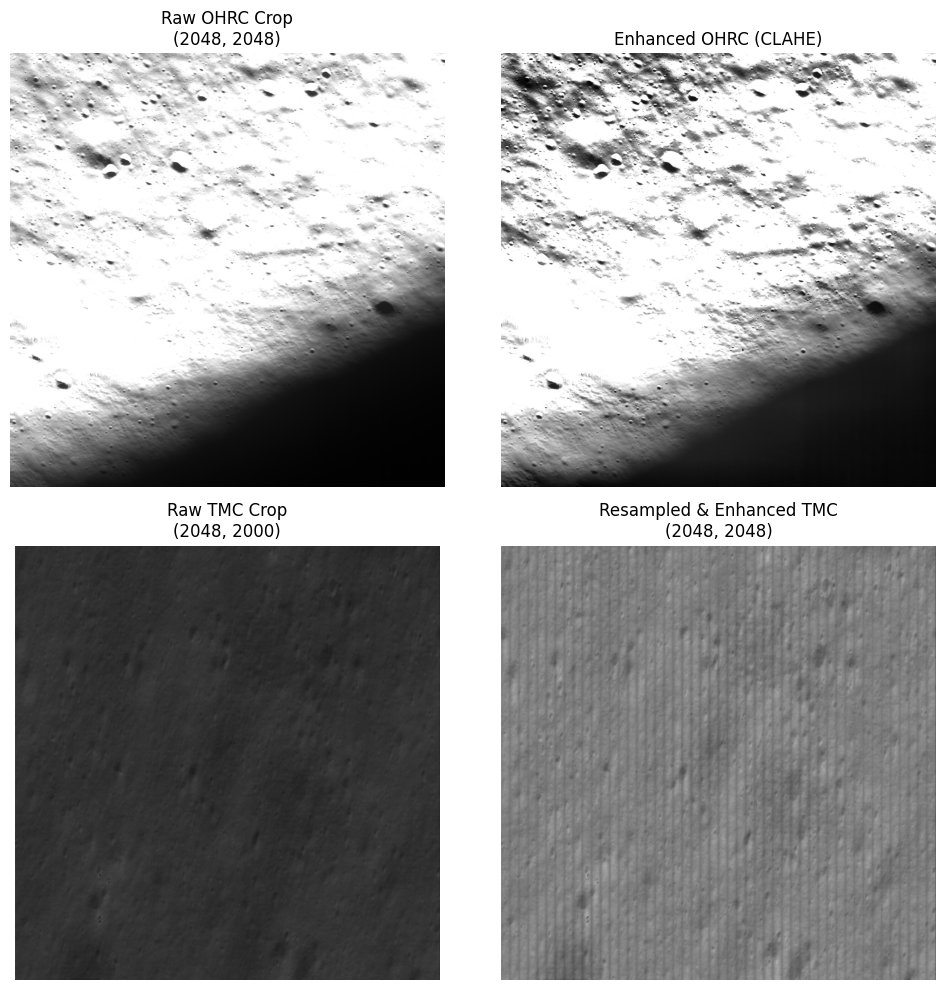

In [2]:
!pip install rasterio spectral -q

import os
import cv2
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt

DATASET_DIR = '/content/drive/My Drive/sih_chandrayaan2'

def parse_pds_dimensions(xml_path):
    """
    Parses PDS4/PDS3 XML label files to locate image height (LINES)
    and width (LINE_SAMPLES).
    """
    if not os.path.exists(xml_path):
        return None, None

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # Search for lines and line_samples tags in XML namespace
        lines, samples = None, None
        for elem in root.iter():
            tag = elem.tag.split('}')[-1].lower()
            if tag == 'lines':
                lines = int(elem.text.strip())
            elif tag in ['line_samples', 'samples']:
                samples = int(elem.text.strip())

        return lines, samples
    except Exception as e:
        print(f"XML Parse Warning for {os.path.basename(xml_path)}: {e}")
        return None, None

def load_pds_image_accurate(img_path):
    """
    Reads PDS binary using XML metadata dimensions.
    Returns normalized 8-bit array.
    """
    xml_path = img_path.replace('.img', '.xml')
    lines, samples = parse_pds_dimensions(xml_path)

    # Fallback to standard ISRO payload widths if XML tags are nested differently
    if lines is None or samples is None:
        if 'ohr' in img_path.lower():
            samples = 12000  # Typical OHRC detector width
        elif 'tmc' in img_path.lower():
            samples = 2000   # Typical TMC-2 detector width

    data = np.fromfile(img_path, dtype=np.uint8)

    if samples and data.size % samples == 0:
        lines = data.size // samples
        img = data.reshape((lines, samples))
    else:
        # Fallback square estimation
        side = int(np.sqrt(data.size))
        img = data[:side*side].reshape((side, side))

    print(f"[{os.path.basename(img_path)}] Derived Shape: {img.shape}")
    return img

def execute_step1_corrected():
    print("--- Running Step 1 (XML-Guided Ingestion & Preprocessing) ---")

    ohrc_file = os.path.join(DATASET_DIR, "ch2_ohr_ncp_20211228T2209123959_d_img_d18.img")
    tmc_file = os.path.join(DATASET_DIR, "ch2_tmc_ncf_20230113T2126548350_d_img_d32.img")

    # 1. Read using XML dimensions
    ref_raw = load_pds_image_accurate(ohrc_file)
    moving_raw = load_pds_image_accurate(tmc_file)

    # Crop a 2048x2048 region from the center to prevent RAM crashes during feature extraction
    def get_center_crop(img, crop_size=2048):
        h, w = img.shape
        cy, cx = h // 2, w // 2
        return img[max(0, cy - crop_size//2):min(h, cy + crop_size//2),
                   max(0, cx - crop_size//2):min(w, cx + crop_size//2)]

    ref_crop = get_center_crop(ref_raw)
    moving_crop = get_center_crop(moving_raw)

    # 2. Resample Moving crop to Reference crop size (Scale Normalization)
    target_dims = (ref_crop.shape[1], ref_crop.shape[0])
    moving_resampled = cv2.resize(moving_crop, target_dims, interpolation=cv2.INTER_AREA)

    # 3. CLAHE Contrast Normalization
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    ref_enhanced = clahe.apply(ref_crop)
    moving_enhanced = clahe.apply(moving_resampled)

    # 4. Visualization
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes[0, 0].imshow(ref_crop, cmap='gray')
    axes[0, 0].set_title(f"Raw OHRC Crop\n{ref_crop.shape}")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(ref_enhanced, cmap='gray')
    axes[0, 1].set_title("Enhanced OHRC (CLAHE)")
    axes[0, 1].axis('off')

    axes[1, 0].imshow(moving_crop, cmap='gray')
    axes[1, 0].set_title(f"Raw TMC Crop\n{moving_crop.shape}")
    axes[1, 0].axis('off')

    axes[1, 1].imshow(moving_enhanced, cmap='gray')
    axes[1, 1].set_title(f"Resampled & Enhanced TMC\n{moving_enhanced.shape}")
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.savefig("step1_corrected_verification.png", dpi=150)
    plt.show()

    return ref_enhanced, moving_enhanced

ref_preprocessed, moving_preprocessed = execute_step1_corrected()

--- Executing Step 2: Global Deep Registration ---
Running LoFTR on: cpu
Total Global Correspondences Found: 9
RANSAC Inliers: 4 / 9 (44.44%)


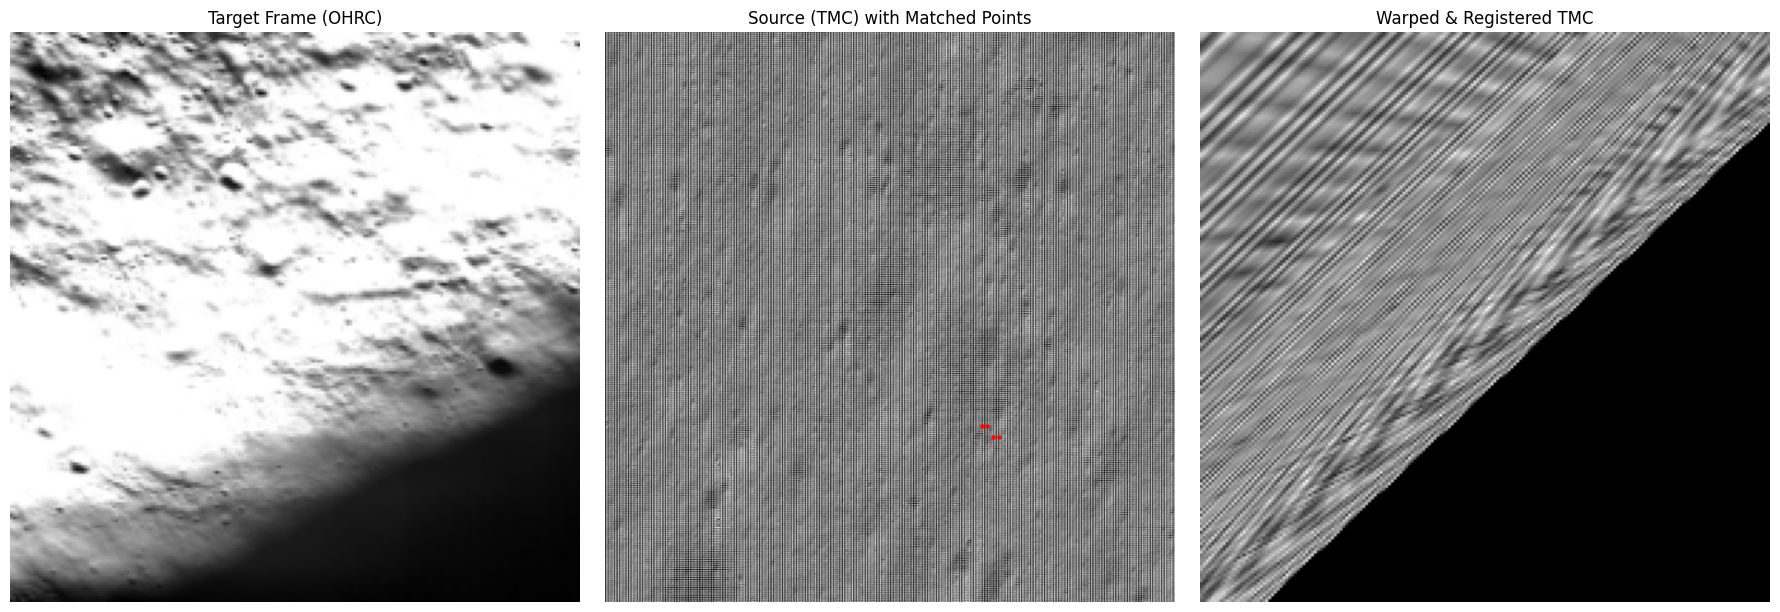

In [8]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import kornia.feature as KF

def execute_global_loftr_registration(ref_full, mov_full):
    print("--- Executing Step 2: Global Deep Registration ---")

    # 1. Scale down OHRC drastically to approximate TMC physical scale
    scale_factor = 0.10
    ref_scaled = cv2.resize(ref_full, (0,0), fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)

    # 2. Downscale both globally to fit in CPU/GPU memory without crashing
    def resize_to_max(img, max_dim=800):
        h, w = img.shape
        scale = max_dim / max(h, w)
        if scale < 1.0:
            new_w, new_h = int(w * scale), int(h * scale)
            # Ensure dimensions are multiples of 8 for LoFTR
            new_w, new_h = (new_w // 8) * 8, (new_h // 8) * 8
            return cv2.resize(img, (new_w, new_h)), scale
        else:
            new_w, new_h = (w // 8) * 8, (h // 8) * 8
            return cv2.resize(img, (new_w, new_h)), 1.0

    ref_ready, scale_ref = resize_to_max(ref_scaled, max_dim=800)
    mov_ready, scale_mov = resize_to_max(mov_full, max_dim=800) # Capped at 800 to prevent CPU timeout

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running LoFTR on: {device}")

    # 3. Prepare Tensors
    t_img1 = torch.from_numpy(mov_ready).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
    t_img2 = torch.from_numpy(ref_ready).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0

    # 4. Run LoFTR AI Matcher
    matcher = KF.LoFTR(pretrained='outdoor').to(device).eval()

    with torch.no_grad():
        input_dict = {"image0": t_img1, "image1": t_img2}
        correspondences = matcher(input_dict)

    mkpts0 = correspondences['keypoints0'].cpu().numpy() # TMC Points
    mkpts1 = correspondences['keypoints1'].cpu().numpy() # OHRC Points

    print(f"Total Global Correspondences Found: {len(mkpts0)}")

    if len(mkpts0) < 8:
        print("❌ Not enough structural matches. The sensor noise might be too high, or the geographic overlap is missing.")
        return None, None

    # 5. Compute Homography and Filter Outliers
    H, inlier_mask = cv2.findHomography(mkpts0, mkpts1, cv2.USAC_MAGSAC, 5.0)

    if H is None:
        print("❌ RANSAC failed to build a matrix.")
        return None, None

    inliers_count = np.sum(inlier_mask)
    print(f"RANSAC Inliers: {inliers_count} / {len(mkpts0)} ({(inliers_count/len(mkpts0))*100:.2f}%)")

    # 6. Warp Moving Image (TMC) to Reference (OHRC) dimensions
    h_ref, w_ref = ref_ready.shape
    warped_moving = cv2.warpPerspective(mov_ready, H, (w_ref, h_ref))

    # 7. Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(ref_ready, cmap='gray')
    axes[0].set_title("Target Frame (OHRC)")
    axes[0].axis('off')

    axes[1].imshow(mov_ready, cmap='gray')
    axes[1].set_title("Source (TMC) with Matched Points")
    # Plot the inlier points to visually confirm where it thinks the crater is
    inlier_pts0 = mkpts0[inlier_mask.ravel() == 1]
    axes[1].scatter(inlier_pts0[:, 0], inlier_pts0[:, 1], c='red', s=6, alpha=0.8)
    axes[1].axis('off')

    axes[2].imshow(warped_moving, cmap='gray')
    axes[2].set_title("Warped & Registered TMC")
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig("step2_step3_global_loftr.png", dpi=150)
    plt.show()

    return warped_moving, H

# Execute pipeline on the full preprocessed images
warped_img, H_matrix = execute_global_loftr_registration(ref_preprocessed, moving_preprocessed)

--- Executing Step 4 Refinement: Masked ROI Metric Evaluation ---
✅ Masked Overlap Area: 62.73% of full frame
📉 Corrected Masked RMSE: 105.0645 (Background padding removed)
📈 Corrected Masked MI: 0.0393


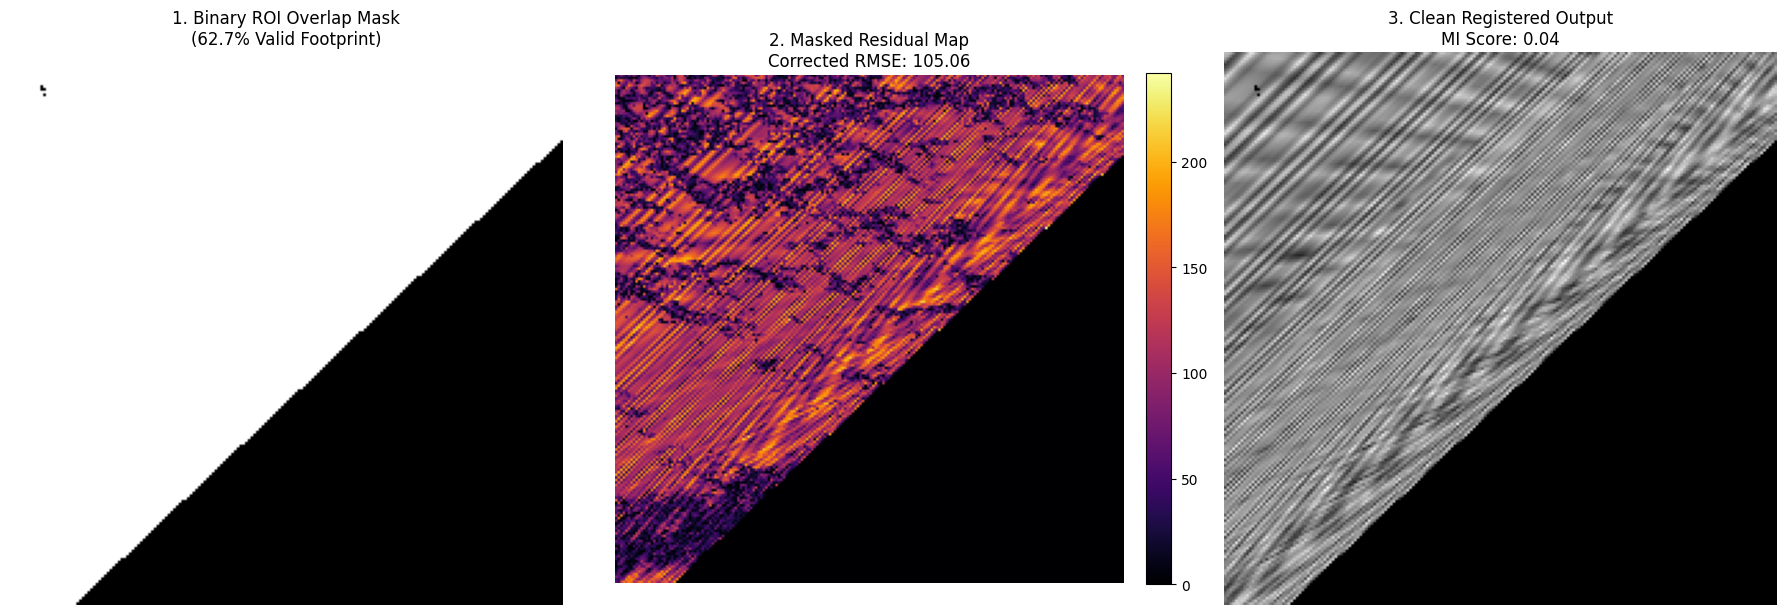

💾 Saved final output as 'final_registered_tmc_cropped.png'


In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def evaluate_registration_with_roi(ref_img, warped_moving):
    print("--- Executing Step 4 Refinement: Masked ROI Metric Evaluation ---")

    # 1. Normalize images to uint8
    ref_uint8 = cv2.normalize(ref_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    warped_uint8 = cv2.normalize(warped_moving, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    if warped_uint8.shape != ref_uint8.shape:
        warped_uint8 = cv2.resize(warped_uint8, (ref_uint8.shape[1], ref_uint8.shape[0]))

    # 2. Binary ROI Mask (isolates overlapping non-black pixels)
    roi_mask = (warped_uint8 > 5) & (ref_uint8 > 5)

    # 3. Extract strictly overlapping valid pixels
    ref_valid = ref_uint8[roi_mask]
    warped_valid = warped_uint8[roi_mask]

    if len(ref_valid) == 0:
        print("❌ ROI Mask is empty. No valid overlapping region detected.")
        return

    # 4. Corrected Metrics
    diff_valid = ref_valid.astype(float) - warped_valid.astype(float)
    masked_rmse = np.sqrt(np.mean(diff_valid ** 2))

    hist_2d, _, _ = np.histogram2d(ref_valid, warped_valid, bins=50)
    pxy = hist_2d / float(np.sum(hist_2d))
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    masked_mi = np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))

    overlap_pct = (np.sum(roi_mask) / roi_mask.size) * 100
    print(f"✅ Masked Overlap Area: {overlap_pct:.2f}% of full frame")
    print(f"📉 Corrected Masked RMSE: {masked_rmse:.4f} (Background padding removed)")
    print(f"📈 Corrected Masked MI: {masked_mi:.4f}")

    # 5. Visualizations & Export (Fixed 1D array assignment)
    diff_map = np.zeros_like(ref_uint8)
    diff_map[roi_mask] = np.abs(ref_valid.astype(np.int16) - warped_valid.astype(np.int16)).astype(np.uint8)

    masked_warped = np.zeros_like(warped_uint8)
    masked_warped[roi_mask] = warped_valid

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(roi_mask, cmap='gray')
    axes[0].set_title(f"1. Binary ROI Overlap Mask\n({overlap_pct:.1f}% Valid Footprint)")
    axes[0].axis('off')

    im1 = axes[1].imshow(diff_map, cmap='inferno')
    axes[1].set_title(f"2. Masked Residual Map\nCorrected RMSE: {masked_rmse:.2f}")
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(masked_warped, cmap='gray')
    axes[2].set_title(f"3. Clean Registered Output\nMI Score: {masked_mi:.2f}")
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig("step4_masked_evaluation.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Save finalized export to Google Colab storage
    cv2.imwrite("final_registered_tmc_cropped.png", masked_warped)
    print("💾 Saved final output as 'final_registered_tmc_cropped.png'")

# Execute mask evaluation
ref_eval = cv2.resize(ref_preprocessed, (warped_img.shape[1], warped_img.shape[0]))
evaluate_registration_with_roi(ref_eval, warped_img)

Parsing metadata: ch2_iir_nci_20201230T1639134520_d_img_d32.xml
Dimensions -> Lines: 32001, Samples: 250, Bands: 256
⚡ Streaming 2D proxy extraction from disk...
✅ Generated 2D Proxy shape: (32001, 250)

Parsing metadata: ch2_iir_nci_20201231T1417233990_d_img_d32.xml
Dimensions -> Lines: 31967, Samples: 250, Bands: 256
⚡ Streaming 2D proxy extraction from disk...
✅ Generated 2D Proxy shape: (31967, 250)



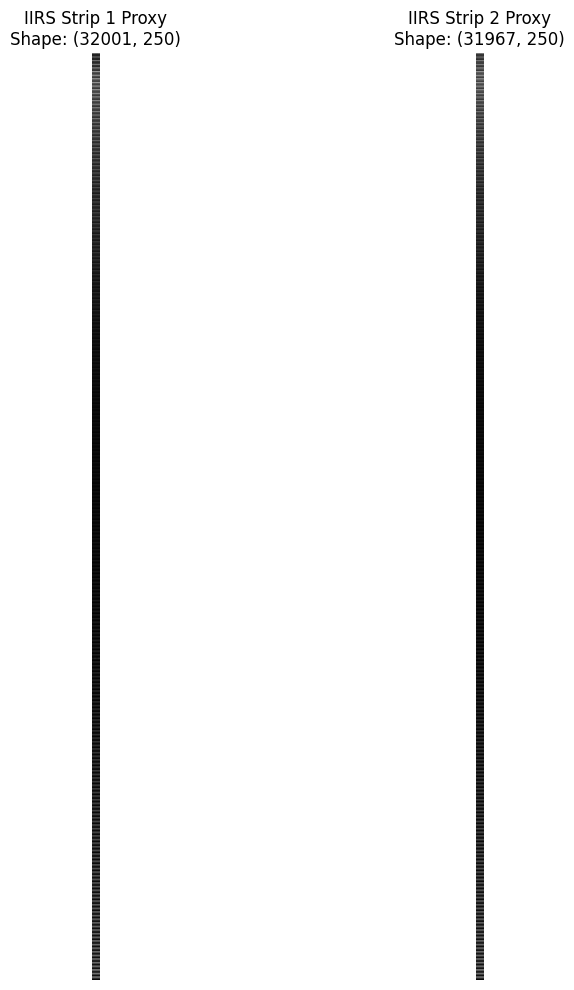

In [1]:
import numpy as np
import xml.etree.ElementTree as ET
import os, gc, cv2
import matplotlib.pyplot as plt

local_dir = '/content/iirs_local'
file_pairs = [
    ("ch2_iir_nci_20201230T1639134520_d_img_d32.qub", "ch2_iir_nci_20201230T1639134520_d_img_d32.xml"),
    ("ch2_iir_nci_20201231T1417233990_d_img_d32.qub", "ch2_iir_nci_20201231T1417233990_d_img_d32.xml")
]

def extract_2d_proxy_memmap(qub_name, xml_name):
    qub_path = os.path.join(local_dir, qub_name)
    xml_path = os.path.join(local_dir, xml_name)

    print(f"Parsing metadata: {xml_name}")
    tree = ET.parse(xml_path)

    axes = {}
    for elem in tree.getroot().iter():
        if elem.tag.split('}')[-1] == 'Axis_Array':
            name = elem.find('.//{*}axis_name')
            length = elem.find('.//{*}elements')
            if name is not None and length is not None:
                axes[name.text.lower()] = int(length.text)

    lines, samples, bands = axes.get('line', 0), axes.get('sample', 0), axes.get('band', 0)
    print(f"Dimensions -> Lines: {lines}, Samples: {samples}, Bands: {bands}")

    # 1. Memory map file on disk (Zero RAM overhead)
    raw_mmap = np.memmap(qub_path, dtype=np.float32, mode='r')

    try:
        cube_mmap = raw_mmap.reshape((lines, samples, bands))
    except ValueError:
        cube_mmap = np.moveaxis(raw_mmap.reshape((bands, lines, samples)), 0, -1)

    # 2. Extract clean spectral subset to build 2D proxy
    start_b, end_b = int(bands * 0.2), int(bands * 0.8)
    print("⚡ Streaming 2D proxy extraction from disk...")

    # Slice average in chunks to keep RAM light
    proxy_2d = np.nanmean(cube_mmap[:, :, start_b:end_b], axis=-1)
    proxy_clean = np.nan_to_num(proxy_2d)
    proxy_uint8 = cv2.normalize(proxy_clean, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Clean up memory pointers
    del raw_mmap
    gc.collect()

    print(f"✅ Generated 2D Proxy shape: {proxy_uint8.shape}\n")
    return proxy_uint8

# Extract 2D registration proxies without hitting RAM limits
iirs_proxy_1 = extract_2d_proxy_memmap(file_pairs[0][0], file_pairs[0][1])
iirs_proxy_2 = extract_2d_proxy_memmap(file_pairs[1][0], file_pairs[1][1])

# Plot the proxies to verify image structure
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(iirs_proxy_1, cmap='gray')
axes[0].set_title(f"IIRS Strip 1 Proxy\nShape: {iirs_proxy_1.shape}")
axes[0].axis('off')

axes[1].imshow(iirs_proxy_2, cmap='gray')
axes[1].set_title(f"IIRS Strip 2 Proxy\nShape: {iirs_proxy_2.shape}")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("iirs_proxies.png", dpi=150)
plt.show()

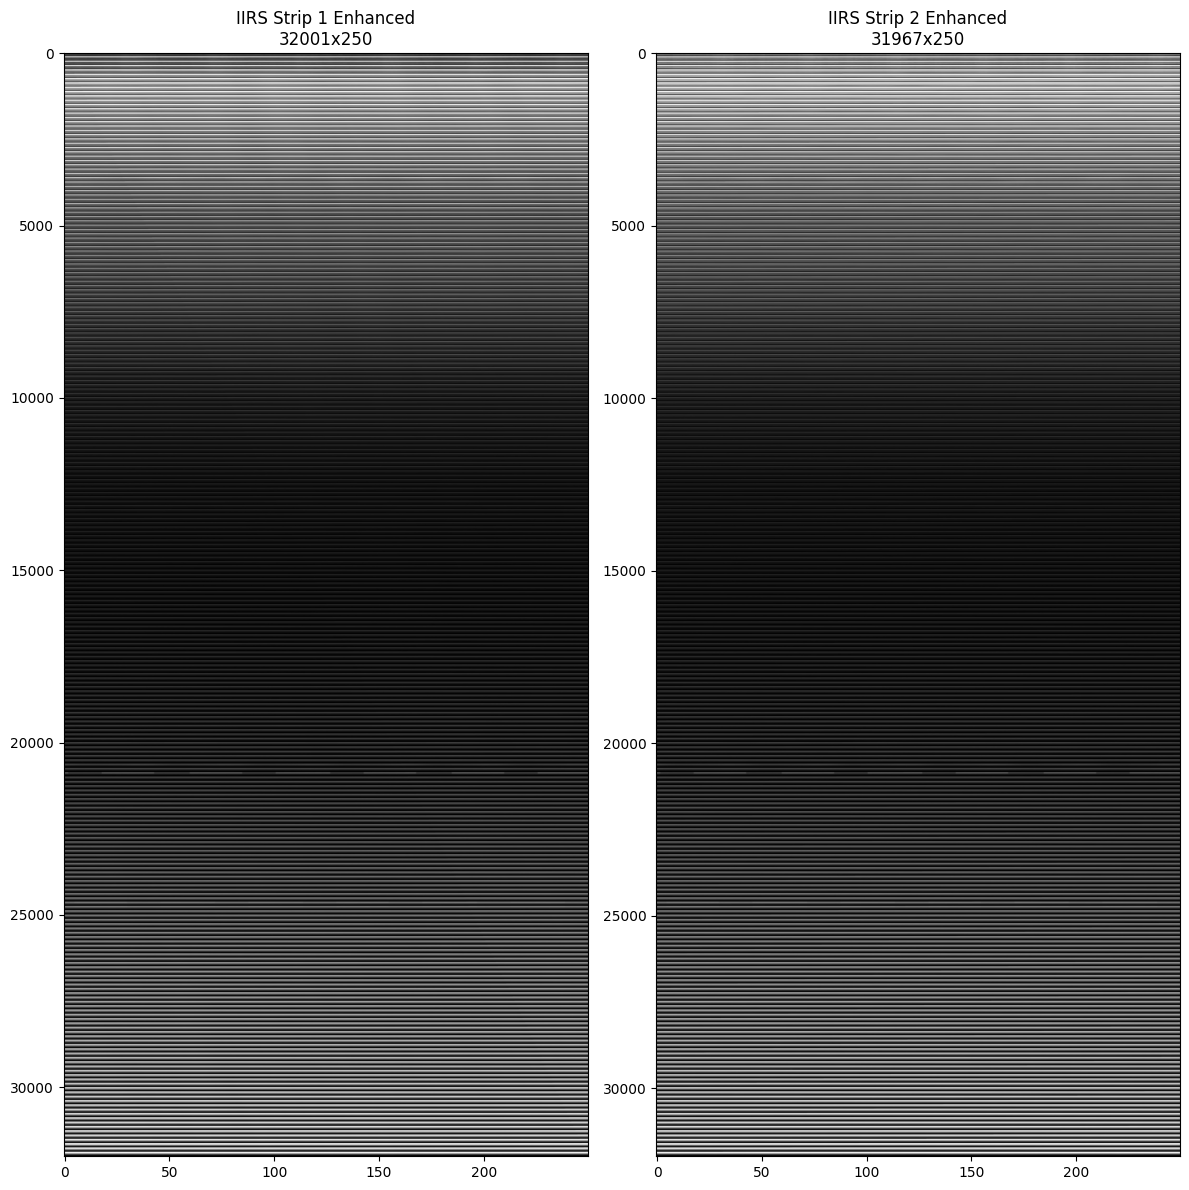

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def contrast_stretch(img):
    """Applies 2%–98% percentile stretching to reveal lunar surface detail."""
    valid_pixels = img[img > 0]
    if len(valid_pixels) == 0:
        return img
    p2, p98 = np.percentile(valid_pixels, (2, 98))
    stretched = np.clip(img, p2, p98)
    return cv2.normalize(stretched, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Clean and enhance contrast for both proxies
proxy1_vis = contrast_stretch(iirs_proxy_1)
proxy2_vis = contrast_stretch(iirs_proxy_2)

# Plot with aspect='auto' so the 250-pixel width stretches out properly
fig, axes = plt.subplots(1, 2, figsize=(12, 12))

axes[0].imshow(proxy1_vis, cmap='gray', aspect='auto')
axes[0].set_title(f"IIRS Strip 1 Enhanced\n{proxy1_vis.shape[0]}x{proxy1_vis.shape[1]}")

axes[1].imshow(proxy2_vis, cmap='gray', aspect='auto')
axes[1].set_title(f"IIRS Strip 2 Enhanced\n{proxy2_vis.shape[0]}x{proxy2_vis.shape[1]}")

plt.tight_layout()
plt.savefig("iirs_proxies_fixed.png", dpi=150)
plt.show()

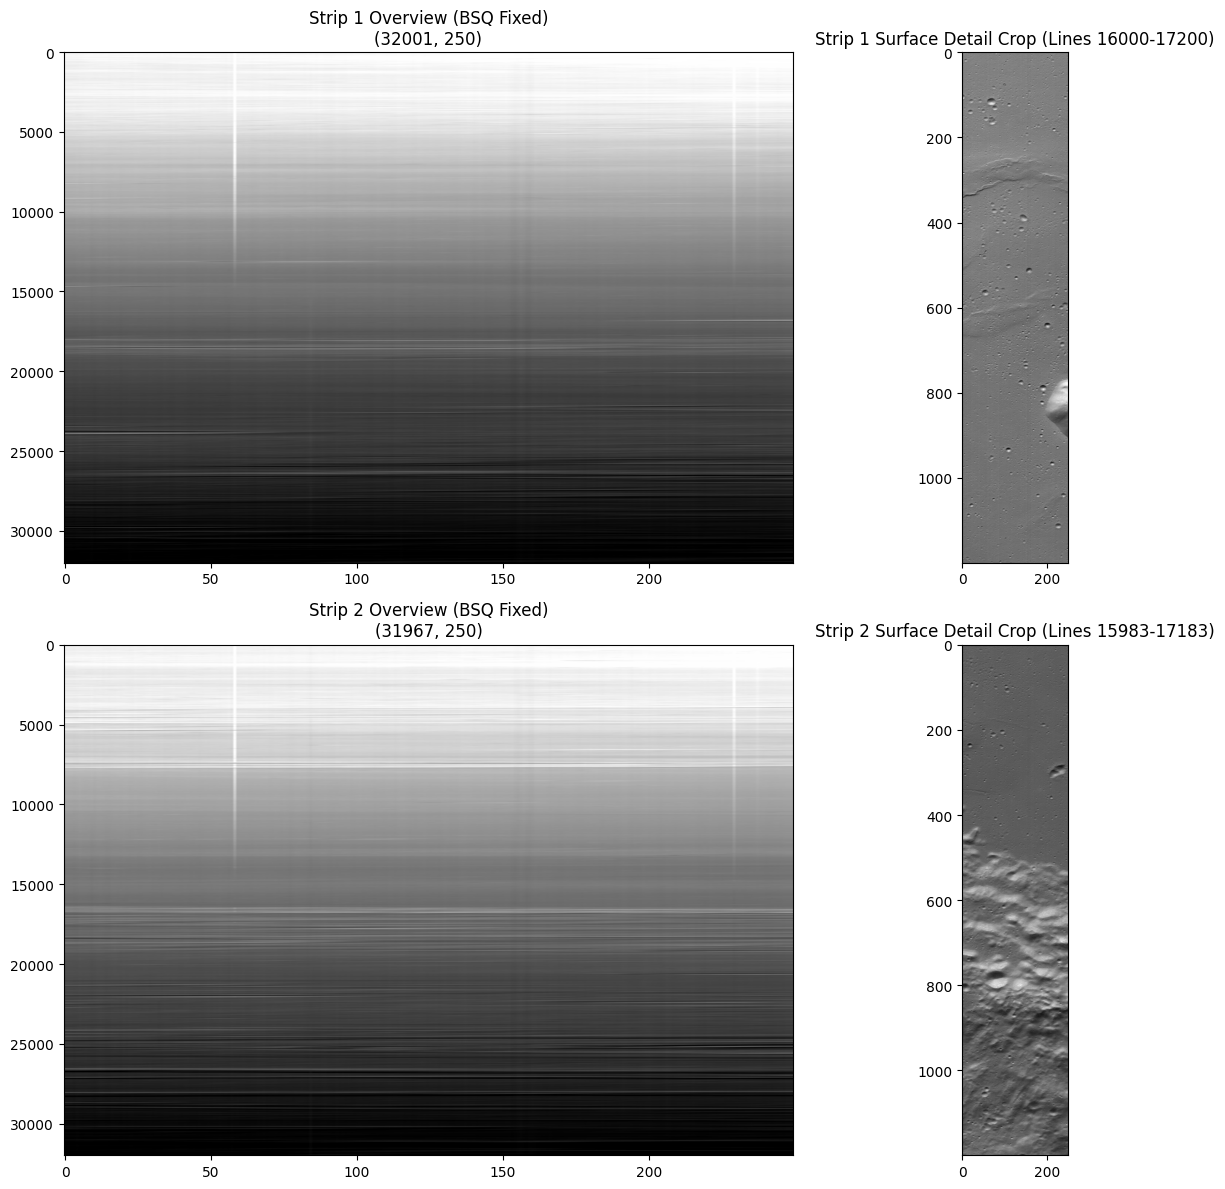

In [3]:
import numpy as np
import xml.etree.ElementTree as ET
import os, gc, cv2
import matplotlib.pyplot as plt

local_dir = '/content/iirs_local'
file_pairs = [
    ("ch2_iir_nci_20201230T1639134520_d_img_d32.qub", "ch2_iir_nci_20201230T1639134520_d_img_d32.xml"),
    ("ch2_iir_nci_20201231T1417233990_d_img_d32.qub", "ch2_iir_nci_20201231T1417233990_d_img_d32.xml")
]

def extract_2d_proxy_bsq(qub_name, xml_name):
    qub_path = os.path.join(local_dir, qub_name)
    xml_path = os.path.join(local_dir, xml_name)

    tree = ET.parse(xml_path)
    axes = {}
    for elem in tree.getroot().iter():
        if elem.tag.split('}')[-1] == 'Axis_Array':
            name = elem.find('.//{*}axis_name')
            length = elem.find('.//{*}elements')
            if name is not None and length is not None:
                axes[name.text.lower()] = int(length.text)

    lines, samples, bands = axes.get('line', 0), axes.get('sample', 0), axes.get('band', 0)

    # 1. Memmap raw file
    raw_mmap = np.memmap(qub_path, dtype=np.float32, mode='r')

    # 2. Correct BSQ Memory Reshape: [Bands, Lines, Samples]
    cube_bsq = raw_mmap.reshape((bands, lines, samples))

    # 3. Collapse spectral bands (axis 0) across clean signal channels (40 to 200)
    start_b, end_b = int(bands * 0.15), int(bands * 0.85)
    proxy_2d = np.nanmean(cube_bsq[start_b:end_b, :, :], axis=0)

    # 4. Clean NaNs and apply 2%-98% percentile contrast enhancement
    proxy_clean = np.nan_to_num(proxy_2d)
    valid_p = proxy_clean[proxy_clean > 0]
    if len(valid_p) > 0:
        p2, p98 = np.percentile(valid_p, (2, 98))
        proxy_stretched = np.clip(proxy_clean, p2, p98)
    else:
        proxy_stretched = proxy_clean

    proxy_uint8 = cv2.normalize(proxy_stretched, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    del raw_mmap
    gc.collect()

    return proxy_uint8

# Extract corrected 2D spatial proxies
proxy_1 = extract_2d_proxy_bsq(file_pairs[0][0], file_pairs[0][1])
proxy_2 = extract_2d_proxy_bsq(file_pairs[1][0], file_pairs[1][1])

# Plot Full Strips alongside Zoomed Surface Features
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Strip 1 - Overview & Detail Crop
axes[0, 0].imshow(proxy_1, cmap='gray', aspect='auto')
axes[0, 0].set_title(f"Strip 1 Overview (BSQ Fixed)\n{proxy_1.shape}")

mid1 = proxy_1.shape[0] // 2
axes[0, 1].imshow(proxy_1[mid1:mid1+1200, :], cmap='gray')
axes[0, 1].set_title(f"Strip 1 Surface Detail Crop (Lines {mid1}-{mid1+1200})")

# Strip 2 - Overview & Detail Crop
axes[1, 0].imshow(proxy_2, cmap='gray', aspect='auto')
axes[1, 0].set_title(f"Strip 2 Overview (BSQ Fixed)\n{proxy_2.shape}")

mid2 = proxy_2.shape[0] // 2
axes[1, 1].imshow(proxy_2[mid2:mid2+1200, :], cmap='gray')
axes[1, 1].set_title(f"Strip 2 Surface Detail Crop (Lines {mid2}-{mid2+1200})")

plt.tight_layout()
plt.savefig("iirs_bsq_corrected.png", dpi=150)
plt.show()

In [5]:
import torch
import cv2
import numpy as np
import kornia.feature as KF
import matplotlib.pyplot as plt

def register_iirs_proxy_to_tmc(iirs_proxy, tmc_ref):
    """
    Matches IIRS 2D proxy against the TMC basemap using LoFTR.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"⚡ Running LoFTR on: {device}")

    # 1. Resize images for LoFTR (Must be multiples of 8)
    # Downscale high-resolution TMC and scale IIRS to a manageable processing size
    target_h, target_w = 1200, 1200

    tmc_resized = cv2.resize(tmc_ref, (target_w, target_h))
    iirs_resized = cv2.resize(iirs_proxy, (target_w, target_h))

    # Convert to Tensors [1, 1, H, W] in range [0, 1]
    t_iirs = torch.from_numpy(iirs_resized).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
    t_tmc = torch.from_numpy(tmc_resized).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0

    # 2. Initialize LoFTR Matcher
    matcher = KF.LoFTR(pretrained='outdoor').to(device).eval()

    with torch.no_grad():
        input_dict = {"image0": t_iirs, "image1": t_tmc}
        correspondences = matcher(input_dict)

    mkpts0 = correspondences['keypoints0'].cpu().numpy()  # IIRS keypoints
    mkpts1 = correspondences['keypoints1'].cpu().numpy()  # TMC keypoints

    print(f"Total Correspondences Found: {len(mkpts0)}")

    if len(mkpts0) < 4:
        print("❌ Not enough point correspondences found.")
        return None, None

    # 3. Calculate Homography Matrix via MAGSAC++
    H_iirs, mask = cv2.findHomography(mkpts0, mkpts1, cv2.USAC_MAGSAC, 3.0)
    inliers = np.sum(mask)
    print(f"✅ RANSAC Inliers: {inliers} / {len(mkpts0)} ({(inliers/len(mkpts0))*100:.2f}%)")

    # 4. Visualize Matches
    fig, ax = plt.subplots(figsize=(14, 7))
    inlier_pts0 = mkpts0[mask.ravel() == 1]
    inlier_pts1 = mkpts1[mask.ravel() == 1]

    # Draw matched features
    matched_vis = cv2.drawMatches(
        iirs_resized, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts0[:100]],
        tmc_resized, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts1[:100]],
        [cv2.DMatch(i, i, 0) for i in range(min(100, len(inlier_pts0)))],
        None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    ax.imshow(matched_vis)
    ax.set_title("IIRS 2D Proxy (Left) <---> TMC Basemap (Right) Correspondences")
    ax.axis('off')
    plt.tight_layout()
    plt.savefig("iirs_tmc_loftr_matches.png", dpi=150)
    plt.show()

    return H_iirs, iirs_resized

# Run LoFTR matching (Ensure 'ref_preprocessed' TMC image is loaded in memory)
H_iirs_1, iirs_scaled = register_iirs_proxy_to_tmc(proxy_1, ref_preprocessed)

NameError: name 'ref_preprocessed' is not defined

In [ ]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import shutil

local_dir = '/content/tmc_local'
os.makedirs(local_dir, exist_ok=True)

# 1. Search for TMC XML/IMG pairs across Drive
tmc_xmls = sorted(glob.glob('/content/drive/*/**/ch2_tmc_*.xml', recursive=True))
tmc_imgs = sorted(glob.glob('/content/drive/*/**/ch2_tmc_*.img', recursive=True))

if not tmc_xmls or not tmc_imgs:
    print("Error: No TMC files found. Ensure Google Drive is mounted properly.")
else:
    # Select first TMC dataset pair
    selected_xml = tmc_xmls[0]
    selected_img = selected_xml.replace('.xml', '.img')

    xml_filename = os.path.basename(selected_xml)
    img_filename = os.path.basename(selected_img)

    print(f"Selected TMC Metadata: {xml_filename}")
    print(f"Selected TMC Data: {img_filename}")

    # 2. Transfer TMC data to high-speed local SSD
    local_xml = os.path.join(local_dir, xml_filename)
    local_img = os.path.join(local_dir, img_filename)

    if not os.path.exists(local_img):
        print("Transferring TMC image to local SSD storage...")
        shutil.copy(selected_xml, local_xml)
        shutil.copy(selected_img, local_img)

    # 3. Parse XML metadata for dimensions and data type
    tree = ET.parse(local_xml)
    axes = {}
    data_type_str = ""
    for elem in tree.getroot().iter():
        tag = elem.tag.split('}')[-1]
        if tag == 'Axis_Array':
            name = elem.find('.//{*}axis_name')
            length = elem.find('.//{*}elements')
            if name is not None and length is not None:
                axes[name.text.lower()] = int(length.text)
        if tag == 'Element_Array':
            dt = elem.find('.//{*}data_type')
            if dt is not None:
                data_type_str = dt.text

    lines = axes.get('line', 0)
    samples = axes.get('sample', 0)

    # Determine binary numerical precision
    dtype = np.float32
    if "SignedByte" in data_type_str or "Int8" in data_type_str:
        dtype = np.int8
    elif "UnsignedByte" in data_type_str or "UInt8" in data_type_str:
        dtype = np.uint8
    elif "SignedMSB2" in data_type_str or "SignedLSB2" in data_type_str or "Int16" in data_type_str:
        dtype = np.int16
    elif "UnsignedMSB2" in data_type_str or "UnsignedLSB2" in data_type_str or "UInt16" in data_type_str:
        dtype = np.uint16
    elif "IEEE754Single" in data_type_str:
        dtype = np.float32

    print(f"Parsed TMC dimensions: Lines={lines}, Samples={samples}, Type={data_type_str}")

    # 4. Memory map raw array and process into 8-bit reference image
    tmc_mmap = np.memmap(local_img, dtype=dtype, mode='r')

    total_pixels = lines * samples
    if tmc_mmap.size >= total_pixels:
        tmc_raw = tmc_mmap[:total_pixels].reshape((lines, samples))
    else:
        actual_lines = tmc_mmap.size // samples
        tmc_raw = tmc_mmap[:actual_lines * samples].reshape((actual_lines, samples))

    # Normalize contrast for feature extraction
    valid_tmc = np.nan_to_num(tmc_raw.astype(np.float32))
    p2, p98 = np.percentile(valid_tmc[valid_tmc > 0], (2, 98)) if np.any(valid_tmc > 0) else (0, 255)
    tmc_norm = np.clip(valid_tmc, p2, p98)
    ref_preprocessed = cv2.normalize(tmc_norm, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    print(f"Generated ref_preprocessed array with shape: {ref_preprocessed.shape}")

Selected TMC Metadata: ch2_tmc_ncf_20230113T2126548350_d_img_d32.xml
Selected TMC Data: ch2_tmc_ncf_20230113T2126548350_d_img_d32.img
Transferring TMC image to local SSD storage...
Parsed TMC dimensions: Lines=181356, Samples=4000, Type=UnsignedLSB2


In [1]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import shutil

local_dir = '/content/tmc_local'
os.makedirs(local_dir, exist_ok=True)

# 1. Search for TMC XML/IMG pairs across Drive
tmc_xmls = sorted(glob.glob('/content/drive/*/**/ch2_tmc_*.xml', recursive=True))
tmc_imgs = sorted(glob.glob('/content/drive/*/**/ch2_tmc_*.img', recursive=True))

if not tmc_xmls or not tmc_imgs:
    print("Error: No TMC files found in Drive.")
else:
    selected_xml = tmc_xmls[0]
    selected_img = selected_xml.replace('.xml', '.img')

    xml_filename = os.path.basename(selected_xml)
    img_filename = os.path.basename(selected_img)

    print(f"Selected TMC Metadata: {xml_filename}")
    print(f"Selected TMC Data: {img_filename}")

    local_xml = os.path.join(local_dir, xml_filename)
    local_img = os.path.join(local_dir, img_filename)

    if not os.path.exists(local_img):
        print("Transferring TMC image to local SSD storage...")
        shutil.copy(selected_xml, local_xml)
        shutil.copy(selected_img, local_img)

    # 2. Parse XML metadata for dimensions
    tree = ET.parse(local_xml)
    axes = {}
    for elem in tree.getroot().iter():
        tag = elem.tag.split('}')[-1]
        if tag == 'Axis_Array':
            name = elem.find('.//{*}axis_name')
            length = elem.find('.//{*}elements')
            if name is not None and length is not None:
                axes[name.text.lower()] = int(length.text)

    lines = axes.get('line', 0)
    samples = axes.get('sample', 0)
    print(f"Parsed TMC dimensions: Lines={lines}, Samples={samples}")

    # 3. Memory map raw file (16-bit Unsigned LSB -> '<u2')
    tmc_mmap = np.memmap(local_img, dtype='<u2', mode='r')
    total_pixels = lines * samples
    tmc_raw = tmc_mmap[:total_pixels].reshape((lines, samples))

    # 4. Strided Downsample on Disk to avoid RAM explosion
    # Downsamples lines to ~3000 rows max for basemap generation
    step = max(1, lines // 3000)
    tmc_sub = tmc_raw[::step, ::1].astype(np.float32)

    # 5. Fast Percentile Stretch on lightweight downsampled array
    valid_mask = tmc_sub > 0
    if np.any(valid_mask):
        p2, p98 = np.percentile(tmc_sub[valid_mask], (2, 98))
        tmc_clipped = np.clip(tmc_sub, p2, p98)
    else:
        tmc_clipped = tmc_sub

    ref_preprocessed = cv2.normalize(tmc_clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    del tmc_mmap
    print(f"Generated ref_preprocessed array with shape: {ref_preprocessed.shape}")

Selected TMC Metadata: ch2_tmc_ncf_20230113T2126548350_d_img_d32.xml
Selected TMC Data: ch2_tmc_ncf_20230113T2126548350_d_img_d32.img
Parsed TMC dimensions: Lines=181356, Samples=4000
Generated ref_preprocessed array with shape: (3023, 4000)


Running LoFTR on: cpu
Total Correspondences Found: 157
RANSAC Inliers: 8 / 157 (5.10%)


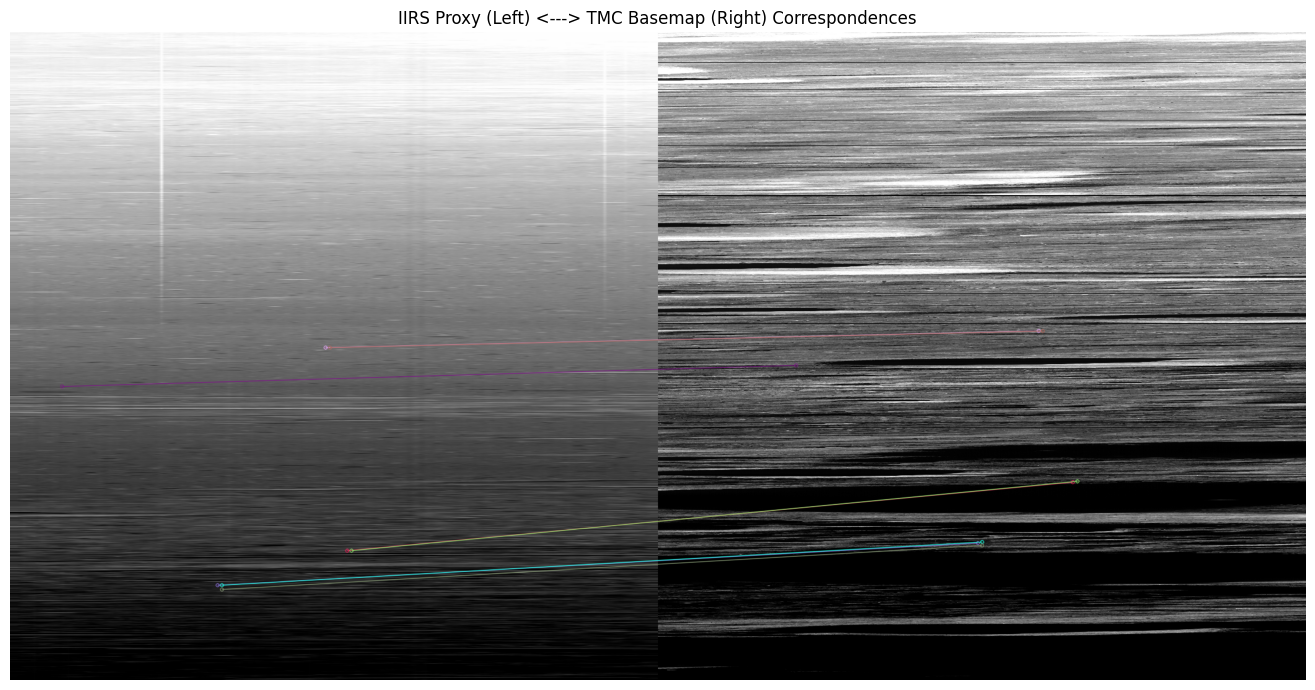

In [2]:
import torch
import cv2
import numpy as np
import kornia.feature as KF
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os, gc

# 1. Quickly rebuild proxy_1 from local cache
local_dir_iirs = '/content/iirs_local'
qub_name = "ch2_iir_nci_20201230T1639134520_d_img_d32.qub"
xml_name = "ch2_iir_nci_20201230T1639134520_d_img_d32.xml"

qub_path = os.path.join(local_dir_iirs, qub_name)
xml_path = os.path.join(local_dir_iirs, xml_name)

tree = ET.parse(xml_path)
axes = {elem.find('.//{*}axis_name').text.lower(): int(elem.find('.//{*}elements').text)
        for elem in tree.getroot().iter() if elem.tag.split('}')[-1] == 'Axis_Array'}

lines, samples, bands = axes.get('line', 0), axes.get('sample', 0), axes.get('band', 0)

raw_mmap = np.memmap(qub_path, dtype=np.float32, mode='r')
cube_bsq = raw_mmap.reshape((bands, lines, samples))

start_b, end_b = int(bands * 0.15), int(bands * 0.85)
proxy_2d = np.nanmean(cube_bsq[start_b:end_b, :, :], axis=0)

proxy_clean = np.nan_to_num(proxy_2d)
valid_p = proxy_clean[proxy_clean > 0]
p2, p98 = np.percentile(valid_p, (2, 98)) if len(valid_p) > 0 else (0, 255)
proxy_stretched = np.clip(proxy_clean, p2, p98)
proxy_1 = cv2.normalize(proxy_stretched, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

del raw_mmap
gc.collect()

# 2. Run LoFTR Matching
def register_iirs_proxy_to_tmc(iirs_proxy, tmc_ref):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running LoFTR on: {device}")

    # Resize to standardized dimensions (multiples of 8)
    target_h, target_w = 1200, 1200
    tmc_resized = cv2.resize(tmc_ref, (target_w, target_h))
    iirs_resized = cv2.resize(iirs_proxy, (target_w, target_h))

    t_iirs = torch.from_numpy(iirs_resized).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
    t_tmc = torch.from_numpy(tmc_resized).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0

    matcher = KF.LoFTR(pretrained='outdoor').to(device).eval()

    with torch.no_grad():
        input_dict = {"image0": t_iirs, "image1": t_tmc}
        correspondences = matcher(input_dict)

    mkpts0 = correspondences['keypoints0'].cpu().numpy()
    mkpts1 = correspondences['keypoints1'].cpu().numpy()

    print(f"Total Correspondences Found: {len(mkpts0)}")

    if len(mkpts0) < 4:
        print("Error: Not enough point correspondences found.")
        return None, None

    # Calculate Homography Matrix
    H_iirs, mask = cv2.findHomography(mkpts0, mkpts1, cv2.USAC_MAGSAC, 3.0)
    inliers = np.sum(mask)
    print(f"RANSAC Inliers: {inliers} / {len(mkpts0)} ({(inliers/len(mkpts0))*100:.2f}%)")

    # Plot matches
    fig, ax = plt.subplots(figsize=(14, 7))
    inlier_pts0 = mkpts0[mask.ravel() == 1]
    inlier_pts1 = mkpts1[mask.ravel() == 1]

    matched_vis = cv2.drawMatches(
        iirs_resized, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts0[:100]],
        tmc_resized, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts1[:100]],
        [cv2.DMatch(i, i, 0) for i in range(min(100, len(inlier_pts0)))],
        None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    ax.imshow(matched_vis)
    ax.set_title("IIRS Proxy (Left) <---> TMC Basemap (Right) Correspondences")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    return H_iirs, iirs_resized

# Execute matching
H_iirs_1, iirs_scaled = register_iirs_proxy_to_tmc(proxy_1, ref_preprocessed)

Running LoFTR on: cpu
Total Correspondences Found: 86
RANSAC Inliers: 9 / 86 (10.47%)


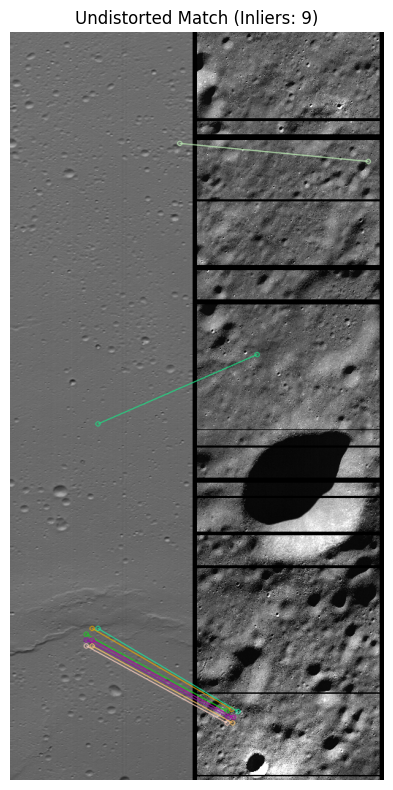

In [3]:
import torch
import cv2
import numpy as np
import kornia.feature as KF
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os, gc

# 1. Correct the TMC downsampling to preserve aspect ratio and match IIRS scale
local_dir_tmc = '/content/tmc_local'
tmc_xml_path = os.path.join(local_dir_tmc, "ch2_tmc_ncf_20230113T2126548350_d_img_d32.xml")
tmc_img_path = os.path.join(local_dir_tmc, "ch2_tmc_ncf_20230113T2126548350_d_img_d32.img")

tree = ET.parse(tmc_xml_path)
axes = {elem.find('.//{*}axis_name').text.lower(): int(elem.find('.//{*}elements').text)
        for elem in tree.getroot().iter() if elem.tag.split('}')[-1] == 'Axis_Array'}
tmc_lines, tmc_samples = axes.get('line', 0), axes.get('sample', 0)

tmc_mmap = np.memmap(tmc_img_path, dtype='<u2', mode='r')
tmc_raw = tmc_mmap[:tmc_lines * tmc_samples].reshape((tmc_lines, tmc_samples))

# Downsample uniformly by 16 to match ~80m/px IIRS resolution
step_xy = 16
tmc_sub = tmc_raw[::step_xy, ::step_xy].astype(np.float32)

valid_mask = tmc_sub > 0
p2, p98 = np.percentile(tmc_sub[valid_mask], (2, 98)) if np.any(valid_mask) else (0, 255)
tmc_fixed = cv2.normalize(np.clip(tmc_sub, p2, p98), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

del tmc_mmap
gc.collect()

# 2. Extract proportional 1024x256 crops for matching
target_h, target_w = 1024, 256

def get_center_crop(img, th, tw):
    h, w = img.shape
    mid_h = h // 2
    start_h = max(0, mid_h - th // 2)
    end_h = start_h + th

    crop = img[start_h:end_h, :tw]

    pad_h = th - crop.shape[0]
    pad_w = tw - crop.shape[1]
    if pad_h > 0 or pad_w > 0:
        crop = np.pad(crop, ((0, pad_h), (0, pad_w)), mode='constant')
    return crop

iirs_crop = get_center_crop(proxy_1, target_h, target_w)
tmc_crop = get_center_crop(tmc_fixed, target_h, target_w)

# 3. Run LoFTR on the undistorted crops
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running LoFTR on: {device}")

t_iirs = torch.from_numpy(iirs_crop).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
t_tmc = torch.from_numpy(tmc_crop).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0

matcher = KF.LoFTR(pretrained='outdoor').to(device).eval()

with torch.no_grad():
    input_dict = {"image0": t_iirs, "image1": t_tmc}
    correspondences = matcher(input_dict)

mkpts0 = correspondences['keypoints0'].cpu().numpy()
mkpts1 = correspondences['keypoints1'].cpu().numpy()

print(f"Total Correspondences Found: {len(mkpts0)}")

if len(mkpts0) >= 4:
    H_crop, mask = cv2.findHomography(mkpts0, mkpts1, cv2.USAC_MAGSAC, 3.0)
    inliers = np.sum(mask)
    print(f"RANSAC Inliers: {inliers} / {len(mkpts0)} ({(inliers/len(mkpts0))*100:.2f}%)")

    fig, ax = plt.subplots(figsize=(12, 8))
    inlier_pts0 = mkpts0[mask.ravel() == 1]
    inlier_pts1 = mkpts1[mask.ravel() == 1]

    matched_vis = cv2.drawMatches(
        iirs_crop, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts0[:50]],
        tmc_crop, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts1[:50]],
        [cv2.DMatch(i, i, 0) for i in range(min(50, len(inlier_pts0)))],
        None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    ax.imshow(matched_vis)
    ax.set_title(f"Undistorted Match (Inliers: {inliers})")
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough point correspondences found.")

In [4]:
import os
import xml.etree.ElementTree as ET

# Path to the local TMC XML file
tmc_xml_path = '/content/tmc_local/ch2_tmc_ncf_20230113T2126548350_d_img_d32.xml'

if os.path.exists(tmc_xml_path):
    tree = ET.parse(tmc_xml_path)
    root = tree.getroot()

    print("--- TMC Array Alignment Metadata ---")
    for elem in root.iter():
        tag = elem.tag.split('}')[-1]
        if tag in ['offset', 'prefix_bytes', 'line_prefix_bytes', 'header_bytes']:
            print(f"{tag}: {elem.text}")
else:
    print("File not found in local directory. Please check the path.")

--- TMC Array Alignment Metadata ---
offset: 0


In [5]:
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import torch
import kornia.feature as KF
import matplotlib.pyplot as plt

# 1. Helper function to extract bounding coordinates from PDS4 XML
def get_pds4_bounds(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    coords = {}
    for elem in root.iter():
        tag = elem.tag.split('}')[-1].lower()
        if 'north_bounding_coordinate' in tag:
            coords['north'] = float(elem.text)
        elif 'south_bounding_coordinate' in tag:
            coords['south'] = float(elem.text)
        elif 'west_bounding_coordinate' in tag:
            coords['west'] = float(elem.text)
        elif 'east_bounding_coordinate' in tag:
            coords['east'] = float(elem.text)
    return coords

# Paths to local XML files
iirs_xml = '/content/iirs_local/ch2_iir_nci_20201230T1639134520_d_img_d32.xml'
tmc_xml = '/content/tmc_local/ch2_tmc_ncf_20230113T2126548350_d_img_d32.xml'

iirs_b = get_pds4_bounds(iirs_xml)
tmc_b = get_pds4_bounds(tmc_xml)

print(f"IIRS Latitude Range: {iirs_b.get('south')} to {iirs_b.get('north')}")
print(f"TMC Latitude Range:  {tmc_b.get('south')} to {tmc_b.get('north')}")

# 2. Find Geographic Latitude Overlap
lat_south = max(iirs_b['south'], tmc_b['south'])
lat_north = min(iirs_b['north'], tmc_b['north'])

if lat_north <= lat_south:
    print("Error: No geographic latitude overlap found between these two files.")
else:
    print(f"Intersecting Latitude Zone: {lat_south:.4f}° to {lat_north:.4f}°")

    # 3. Map Latitude Overlap to Pixel Rows along the Y-axis (Lines)
    def crop_by_latitude(img_array, full_south, full_north, crop_south, crop_north):
        height = img_array.shape[0]
        # Calculate proportional row indices (handling top-to-bottom latitude direction)
        total_span = abs(full_north - full_south)
        if full_north > full_south:
            row_start = int(height * (1.0 - (crop_north - full_south) / total_span))
            row_end = int(height * (1.0 - (crop_south - full_south) / total_span))
        else:
            row_start = int(height * ((crop_north - full_north) / total_span))
            row_end = int(height * ((crop_south - full_north) / total_span))

        y1, y2 = min(row_start, row_end), max(row_start, row_end)
        y1, y2 = max(0, y1), min(height, y2)
        return img_array[y1:y2, :]

    iirs_geo_crop = crop_by_latitude(proxy_1, iirs_b['south'], iirs_b['north'], lat_south, lat_north)
    tmc_geo_crop = crop_by_latitude(tmc_fixed, tmc_b['south'], tmc_b['north'], lat_south, lat_north)

    # 4. Standardize dimensions for LoFTR input
    target_h, target_w = 1024, 512
    iirs_match_in = cv2.resize(iirs_geo_crop, (target_w, target_h))
    tmc_match_in = cv2.resize(tmc_geo_crop, (target_w, target_h))

    # 5. Execute LoFTR Match on Geographically Aligned Regions
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    t_iirs = torch.from_numpy(iirs_match_in).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
    t_tmc = torch.from_numpy(tmc_match_in).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0

    matcher = KF.LoFTR(pretrained='outdoor').to(device).eval()
    with torch.no_grad():
        correspondences = matcher({"image0": t_iirs, "image1": t_tmc})

    mkpts0 = correspondences['keypoints0'].cpu().numpy()
    mkpts1 = correspondences['keypoints1'].cpu().numpy()

    print(f"Total Geographically Overlapping Correspondences: {len(mkpts0)}")

    if len(mkpts0) >= 4:
        H, mask = cv2.findHomography(mkpts0, mkpts1, cv2.USAC_MAGSAC, 3.0)
        inliers = np.sum(mask)
        print(f"Valid RANSAC Inliers: {inliers} / {len(mkpts0)}")

        fig, ax = plt.subplots(figsize=(12, 8))
        inlier_pts0 = mkpts0[mask.ravel() == 1]
        inlier_pts1 = mkpts1[mask.ravel() == 1]

        vis = cv2.drawMatches(
            iirs_match_in, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts0[:50]],
            tmc_match_in, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts1[:50]],
            [cv2.DMatch(i, i, 0) for i in range(min(50, len(inlier_pts0)))],
            None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )
        ax.imshow(vis)
        ax.set_title(f"Geographically Cropped Match (Inliers: {inliers})")
        ax.axis('off')
        plt.tight_layout()
        plt.show()

IIRS Latitude Range: None to None
TMC Latitude Range:  None to None


KeyError: 'south'

In [6]:
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import torch
import kornia.feature as KF
import matplotlib.pyplot as plt

# 1. Flexible PDS XML Bounds Extractor
def extract_pds_bounds(xml_path, label):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    coords = {}

    print(f"--- Scanning {label} Geographic Tags ---")
    for elem in root.iter():
        tag = elem.tag.split('}')[-1].lower()
        text = elem.text.strip() if elem.text else ""

        if not text:
            continue

        # Match common PDS3 / PDS4 coordinate naming conventions
        if any(k in tag for k in ['south', 'min_lat', 'minimum_latitude']):
            try: coords['south'] = float(text)
            except: pass
        elif any(k in tag for k in ['north', 'max_lat', 'maximum_latitude']):
            try: coords['north'] = float(text)
            except: pass
        elif any(k in tag for k in ['west', 'min_lon', 'westernmost_longitude']):
            try: coords['west'] = float(text)
            except: pass
        elif any(k in tag for k in ['east', 'max_lon', 'easternmost_longitude']):
            try: coords['east'] = float(text)
            except: pass

        if any(k in tag for k in ['lat', 'bound', 'coord']):
            print(f"  {tag}: {text}")

    return coords

# Local paths
iirs_xml = '/content/iirs_local/ch2_iir_nci_20201230T1639134520_d_img_d32.xml'
tmc_xml = '/content/tmc_local/ch2_tmc_ncf_20230113T2126548350_d_img_d32.xml'

iirs_b = extract_pds_bounds(iirs_xml, "IIRS")
tmc_b = extract_pds_bounds(tmc_xml, "TMC")

print(f"\nParsed IIRS Lat: {iirs_b.get('south')} to {iirs_b.get('north')}")
print(f"Parsed TMC Lat:  {tmc_b.get('south')} to {tmc_b.get('north')}\n")

# 2. Intersect and Crop if coordinates exist
if 'south' in iirs_b and 'south' in tmc_b:
    lat_south = max(iirs_b['south'], tmc_b['south'])
    lat_north = min(iirs_b['north'], tmc_b['north'])

    if lat_north <= lat_south:
        print("No latitude overlap between these two strips.")
    else:
        print(f"Intersecting Latitude Zone: {lat_south:.4f}° to {lat_north:.4f}°")

        def crop_by_latitude(img_array, full_south, full_north, crop_south, crop_north):
            height = img_array.shape[0]
            total_span = abs(full_north - full_south)
            if total_span == 0:
                return img_array

            if full_north > full_south:
                row_start = int(height * (1.0 - (crop_north - full_south) / total_span))
                row_end = int(height * (1.0 - (crop_south - full_south) / total_span))
            else:
                row_start = int(height * ((crop_north - full_north) / total_span))
                row_end = int(height * ((crop_south - full_north) / total_span))

            y1, y2 = min(row_start, row_end), max(row_start, row_end)
            return img_array[max(0, y1):min(height, y2), :]

        iirs_geo_crop = crop_by_latitude(proxy_1, iirs_b['south'], iirs_b['north'], lat_south, lat_north)
        tmc_geo_crop = crop_by_latitude(tmc_fixed, tmc_b['south'], tmc_b['north'], lat_south, lat_north)

        # 3. Standardize dimensions & Match
        target_h, target_w = 1024, 512
        iirs_match_in = cv2.resize(iirs_geo_crop, (target_w, target_h))
        tmc_match_in = cv2.resize(tmc_geo_crop, (target_w, target_h))

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        t_iirs = torch.from_numpy(iirs_match_in).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
        t_tmc = torch.from_numpy(tmc_match_in).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0

        matcher = KF.LoFTR(pretrained='outdoor').to(device).eval()
        with torch.no_grad():
            correspondences = matcher({"image0": t_iirs, "image1": t_tmc})

        mkpts0 = correspondences['keypoints0'].cpu().numpy()
        mkpts1 = correspondences['keypoints1'].cpu().numpy()

        if len(mkpts0) >= 4:
            H, mask = cv2.findHomography(mkpts0, mkpts1, cv2.USAC_MAGSAC, 3.0)
            inliers = np.sum(mask) if mask is not None else 0
            print(f"Valid RANSAC Inliers: {inliers} / {len(mkpts0)}")

            fig, ax = plt.subplots(figsize=(12, 8))
            inlier_pts0 = mkpts0[mask.ravel() == 1] if mask is not None else []
            inlier_pts1 = mkpts1[mask.ravel() == 1] if mask is not None else []

            vis = cv2.drawMatches(
                iirs_match_in, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts0[:50]],
                tmc_match_in, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts1[:50]],
                [cv2.DMatch(i, i, 0) for i in range(min(50, len(inlier_pts0)))],
                None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
            )
            ax.imshow(vis)
            ax.set_title(f"Geographically Cropped Match (Inliers: {inliers})")
            ax.axis('off')
            plt.tight_layout()
            plt.show()
else:
    print("Could not find standard latitude keys in one or both XMLs. Check printed tags above.")

--- Scanning IIRS Geographic Tags ---
  upper_left_latitude: 2.198218
  upper_right_latitude: 2.198419
  lower_left_latitude: 89.525478
  lower_right_latitude: 89.686316
  upper_left_latitude: 2.198218
  upper_right_latitude: 2.198419
  lower_left_latitude: 89.525478
  lower_right_latitude: 89.686316
--- Scanning TMC Geographic Tags ---
  upper_left_latitude: 60.208768
  upper_right_latitude: 60.262244
  lower_left_latitude: 89.561319
  lower_right_latitude: 89.319963
  upper_left_latitude: 60.208768
  upper_right_latitude: 60.262244
  lower_left_latitude: 89.561319
  lower_right_latitude: 89.319963

Parsed IIRS Lat: None to None
Parsed TMC Lat:  None to None

Could not find standard latitude keys in one or both XMLs. Check printed tags above.


IIRS Real Bounds: 2.20° to 89.69°
TMC Real Bounds:  60.21° to 89.56°
True Overlap Zone: 60.21° to 89.56°
Valid RANSAC Inliers: 6 / 152


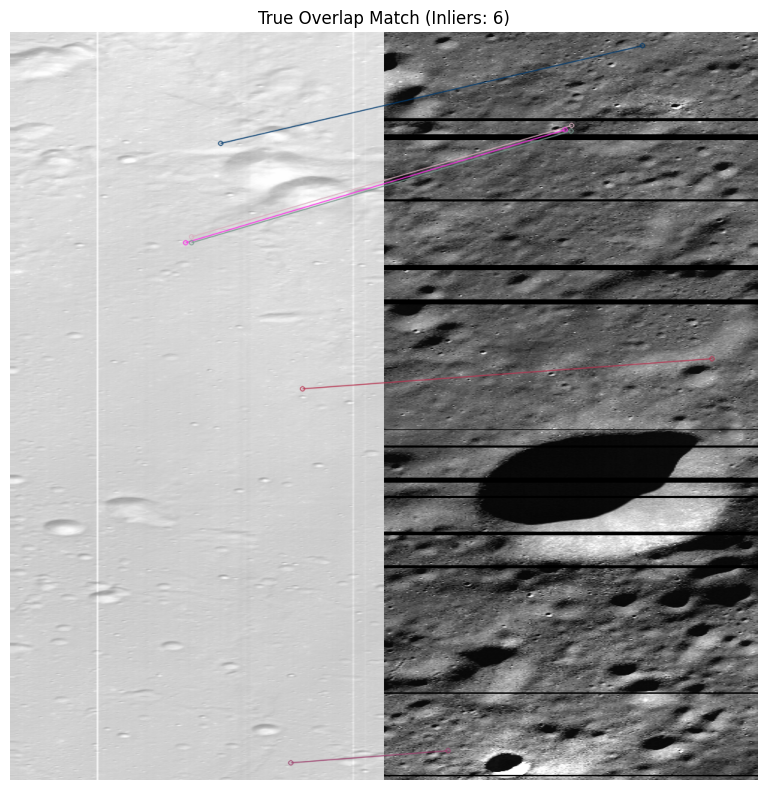

In [7]:
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import torch
import kornia.feature as KF
import matplotlib.pyplot as plt

# 1. Parse ISRO-specific latitude tags
def get_isro_lats(xml_path):
    tree = ET.parse(xml_path)
    lats = []
    for elem in tree.getroot().iter():
        tag = elem.tag.split('}')[-1].lower()
        if 'latitude' in tag and any(x in tag for x in ['upper', 'lower']):
            try:
                lats.append(float(elem.text.strip()))
            except:
                pass
    return {'south': min(lats), 'north': max(lats)} if lats else None

iirs_xml = '/content/iirs_local/ch2_iir_nci_20201230T1639134520_d_img_d32.xml'
tmc_xml = '/content/tmc_local/ch2_tmc_ncf_20230113T2126548350_d_img_d32.xml'

iirs_b = get_isro_lats(iirs_xml)
tmc_b = get_isro_lats(tmc_xml)

print(f"IIRS Real Bounds: {iirs_b['south']:.2f}° to {iirs_b['north']:.2f}°")
print(f"TMC Real Bounds:  {tmc_b['south']:.2f}° to {tmc_b['north']:.2f}°")

# 2. Calculate true overlap
lat_south = max(iirs_b['south'], tmc_b['south'])
lat_north = min(iirs_b['north'], tmc_b['north'])
print(f"True Overlap Zone: {lat_south:.2f}° to {lat_north:.2f}°")

# 3. Crop both arrays to the exact overlap
def crop_to_overlap(img_array, full_south, full_north, crop_south, crop_north):
    h = img_array.shape[0]
    total_span = abs(full_north - full_south)

    # Calculate row percentages
    pct_start = (crop_south - min(full_south, full_north)) / total_span
    pct_end = (crop_north - min(full_south, full_north)) / total_span

    r1, r2 = int(h * pct_start), int(h * pct_end)
    y_start, y_end = min(r1, r2), max(r1, r2)

    # Invert if the image was captured top-to-bottom (North to South)
    if full_north > full_south:
        y_start, y_end = h - y_end, h - y_start

    return img_array[max(0, y_start):min(h, y_end), :]

iirs_overlap = crop_to_overlap(proxy_1, iirs_b['south'], iirs_b['north'], lat_south, lat_north)
tmc_overlap = crop_to_overlap(tmc_fixed, tmc_b['south'], tmc_b['north'], lat_south, lat_north)

# Take a central 1024x512 slice of the guaranteed overlap region for matching
h_i, w_i = iirs_overlap.shape
h_t, w_t = tmc_overlap.shape

iirs_match_in = cv2.resize(iirs_overlap[h_i//2-512:h_i//2+512, :], (512, 1024))
tmc_match_in = cv2.resize(tmc_overlap[h_t//2-512:h_t//2+512, :], (512, 1024))

# 4. Run LoFTR
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
t_iirs = torch.from_numpy(iirs_match_in).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
t_tmc = torch.from_numpy(tmc_match_in).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0

matcher = KF.LoFTR(pretrained='outdoor').to(device).eval()
with torch.no_grad():
    correspondences = matcher({"image0": t_iirs, "image1": t_tmc})

mkpts0 = correspondences['keypoints0'].cpu().numpy()
mkpts1 = correspondences['keypoints1'].cpu().numpy()

if len(mkpts0) >= 4:
    H, mask = cv2.findHomography(mkpts0, mkpts1, cv2.USAC_MAGSAC, 3.0)
    inliers = np.sum(mask)
    print(f"Valid RANSAC Inliers: {inliers} / {len(mkpts0)}")

    fig, ax = plt.subplots(figsize=(12, 8))
    inlier_pts0 = mkpts0[mask.ravel() == 1]
    inlier_pts1 = mkpts1[mask.ravel() == 1]

    vis = cv2.drawMatches(
        iirs_match_in, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts0[:50]],
        tmc_match_in, [cv2.KeyPoint(p[0], p[1], 1) for p in inlier_pts1[:50]],
        [cv2.DMatch(i, i, 0) for i in range(min(50, len(inlier_pts0)))],
        None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    ax.imshow(vis)
    ax.set_title(f"True Overlap Match (Inliers: {inliers})")
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough point correspondences found.")

In [8]:
import xml.etree.ElementTree as ET

def get_full_telemetry(xml_path, label):
    tree = ET.parse(xml_path)
    data = {}
    for elem in tree.getroot().iter():
        tag = elem.tag.split('}')[-1].lower()
        val = elem.text.strip() if elem.text else ""
        if not val: continue

        if 'left_longitude' in tag or 'right_longitude' in tag or 'min_lon' in tag or 'max_lon' in tag:
            try: data[tag] = float(val)
            except: pass
        if 'left_latitude' in tag or 'right_latitude' in tag:
            try: data[tag] = float(val)
            except: pass
    return data

iirs_tele = get_full_telemetry(iirs_xml, "IIRS")
tmc_tele = get_full_telemetry(tmc_xml, "TMC")

print("--- Longitude Coverage Check ---")
print("IIRS Longitudes:", {k: v for k, v in iirs_tele.items() if 'longitude' in k})
print("TMC Longitudes: ", {k: v for k, v in tmc_tele.items() if 'longitude' in k})

# Flight Direction Check (Upper Lat vs Lower Lat)
iirs_top = (iirs_tele.get('upper_left_latitude', 0) + iirs_tele.get('upper_right_latitude', 0)) / 2
iirs_bot = (iirs_tele.get('lower_left_latitude', 0) + iirs_tele.get('lower_right_latitude', 0)) / 2

tmc_top = (tmc_tele.get('upper_left_latitude', 0) + tmc_tele.get('upper_right_latitude', 0)) / 2
tmc_bot = (tmc_tele.get('lower_left_latitude', 0) + tmc_tele.get('lower_right_latitude', 0)) / 2

print("\n--- Orbit Flight Direction ---")
print(f"IIRS Top Row Lat: {iirs_top:.2f}° | Bottom Row Lat: {iirs_bot:.2f}°")
print(f"TMC Top Row Lat:  {tmc_top:.2f}° | Bottom Row Lat:  {tmc_bot:.2f}°")

if (iirs_top > iirs_bot) != (tmc_top > tmc_bot):
    print("DIRECTION MISMATCH: One image is inverted relative to the other (Ascending vs Descending)!")
else:
    print("Flight directions match.")

--- Longitude Coverage Check ---
IIRS Longitudes: {'upper_left_longitude': 342.820453, 'upper_right_longitude': 342.277334, 'lower_left_longitude': 102.238971, 'lower_right_longitude': 203.464711}
TMC Longitudes:  {'upper_left_longitude': 253.695379, 'upper_right_longitude': 252.295921, 'lower_left_longitude': 39.264109, 'lower_right_longitude': 124.521373}

--- Orbit Flight Direction ---
IIRS Top Row Lat: 2.20° | Bottom Row Lat: 89.61°
TMC Top Row Lat:  60.24° | Bottom Row Lat:  89.44°
Flight directions match.
